In [1]:
import pandas as pd
import os
import json
import ast
import collections
from collections import Counter

In [2]:
# let's read excel file and csv files using pandas

In [3]:
attributes=pd.read_excel('attributes.xlsx')
#attributes_19_july=pd.read_excel('attributes-19-july.xlsx')
#finalTree = pd.read_csv('finalTree.csv')
#products = pd.read_csv('productsupdated.csv')

In [4]:
attributes.columns

Index(['id', 'REQUIRED', 'RECOMMENDED', 'OPTIONAL'], dtype='object')

In [5]:
attributes.shape

(457, 4)

# Frequency per product of each class for given attribute attribute
So here we have three attributes (Fabric Type, Accents, Closure).
Let's list down attributes as well as frequency districution plot for each class associated with that attribute

So we define a function where you can pass name of attribute and it will return frequency distribution dataframe

In [35]:
#ast.literal_eval(attributes.RECOMMENDED[0])

In [37]:
#attributes.RECOMMENDED[0]

In [10]:
def get_keys_attributes_str(string):

    keys=[]
    try:
        for j in ast.literal_eval(string):
            for k in list(j.keys()):
                keys.append(k)
    except Exception as e:
        print(e)
        pass
    return keys

In [13]:
get_keys_attributes_str(attributes.RECOMMENDED[2])

['Swim Bottom Style',
 'Character',
 'Theme',
 'Size Type',
 'Pattern',
 'Material',
 'Vintage']

In [48]:
get_keys_attributes_str(attributes.RECOMMENDED[0])

['Performance/Activity',
 'Fabric Wash',
 'Fit',
 'Fabric Type',
 'Character',
 'Country/Region of Manufacture',
 'Material',
 'Occasion',
 'Front Type',
 'Waist Size',
 'Vintage']

In [14]:
'''
This functions takes attributes.column containing multiple strings as input and 
outputs list of keys in that column
'''

def get_keys_attributes_col(data_column):

    keys=[]
    for string in data_column:
        #iterate over each string in given column
        # get keys for given string and append to returnible keys []
        for key in get_keys_attributes_str(string):
            keys.append(key)
    return keys

In [15]:
get_keys_attributes_col(attributes.RECOMMENDED)

EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
unexpected EOF while parsing (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
unexpected EOF while parsing (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
unexpected EOF while parsing (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)
EOL while scanning string literal (<unknown>, line 1)


['Performance/Activity',
 'Fabric Wash',
 'Fit',
 'Fabric Type',
 'Character',
 'Country/Region of Manufacture',
 'Material',
 'Occasion',
 'Front Type',
 'Waist Size',
 'Vintage',
 'Set Includes',
 'Fabric Type',
 'Style',
 'Material',
 'Pattern',
 'Vintage',
 'Number of Pieces',
 'Swim Bottom Style',
 'Character',
 'Theme',
 'Size Type',
 'Pattern',
 'Material',
 'Vintage',
 'Performance/Activity',
 'Closure',
 'Material',
 'Occasion',
 'Waist Size',
 'Inseam',
 'Vintage',
 'Fabric Type',
 'Lining Material',
 'Theme',
 'Features',
 'Character',
 'Season',
 'Insulation Material',
 'Performance/Activity',
 'Closure',
 'Occasion',
 'Vintage',
 'Character',
 'Fabric Type',
 'Material',
 'Vintage',
 'Material',
 'Number in Pack',
 'Closure',
 'Character',
 'Fabric Type',
 'Material',
 'Vintage',
 'Fit',
 'Closure',
 'Material',
 'Waist Size',
 'Inseam',
 'Performance/Activity',
 'Vintage',
 'Occasion',
 'Character Family',
 'Character',
 'Fabric Type',
 'Material',
 'Vintage',
 'Set Inclu

In [55]:
Counter(get_keys_attributes_col(attributes.id))

Counter()

In [16]:
def get_vals_of_attrib_str(attribute,string):

    values=[]
    try:
        for j in ast.literal_eval(string):
            for k in j.keys():
                if k==attribute:
                    for val in j[k]:
                        values.append(val)
    except Exception as e:
        pass
    return values

In [52]:
get_keys_attributes_str(attributes.RECOMMENDED[0])

['Performance/Activity',
 'Fabric Wash',
 'Fit',
 'Fabric Type',
 'Character',
 'Country/Region of Manufacture',
 'Material',
 'Occasion',
 'Front Type',
 'Waist Size',
 'Vintage']

In [8]:
'''
def get_values(data_column):

    values=[]
    for string in data_column:
        try:
            for j in ast.literal_eval(string):
                for k in j.keys():
                    for val in j[k]:
                        values.append(val)
                    #values.append(k)
        except Exception as e:
            pass
    return values
'''

In [17]:
def get_vals_of_attrib(attribute,data_column):

    values=[]
    for string in data_column:
        try:
            for j in ast.literal_eval(string):
                for k in j.keys():
                    if k==attribute:
                        for val in j[k]:
                            values.append(val)
                        #values.append(k)
                        
        except Exception as e:
            pass
    return values

In [19]:
Counter(get_vals_of_attrib('Fabric Wash',attributes.RECOMMENDED))

Counter({'Acid Wash': 12,
         'Charcoal Wash': 12,
         'Dark': 12,
         'Light': 12,
         'Medium': 12,
         'Raw': 12,
         'Rinse': 12,
         'Stone': 12})

In [90]:
def get_freq_vals_attribs(attribute,df_column):
    return Counter(get_vals_of_attrib(attribute,df_column))

In [91]:
get_freq_vals_attribs('Fabric Wash',attributes.RECOMMENDED)

Counter({'Acid Wash': 12,
         'Charcoal Wash': 12,
         'Dark': 12,
         'Light': 12,
         'Medium': 12,
         'Raw': 12,
         'Rinse': 12,
         'Stone': 12})

In [93]:
get_freq_vals_attribs('Closure',attributes.RECOMMENDED)

Counter({'Buckle': 52,
         'Button': 53,
         'Drawstring': 53,
         'Hook & Eye': 50,
         'Hook & Loop': 52,
         'Lace Up': 51,
         'Magnetic': 52,
         'Pull On': 19,
         'Snap': 52,
         'Tie': 53,
         'Zip': 53,
         'Pullover': 24,
         'Push Lock': 12,
         'Toggle': 14,
         'Turn Lock': 12})

<AxesSubplot:>

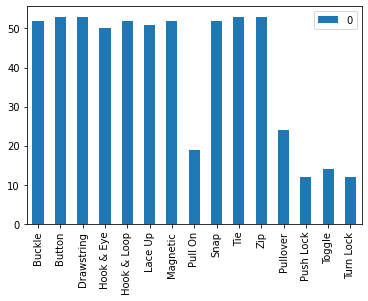

In [117]:
pd.DataFrame.from_dict(Counter(get_freq_vals_attribs('Closure',attributes.RECOMMENDED)),orient='index').plot.bar()

In [73]:
get_values(attributes.RECOMMENDED)

['Baseball',
 'Basketball',
 'Beach',
 'Bodybuilding',
 'Cheerleading',
 'CrossFit',
 'Cross Training',
 'Cycling',
 'Dance',
 'Driving',
 'Fishing',
 'Football',
 'Golf',
 'Gym & Training',
 'Hiking',
 'Hockey',
 'Hunting',
 'Lacrosse',
 'Military',
 'Motorcycle',
 'Pilates',
 'Racing',
 'Riding',
 'Rugby',
 'Running & Jogging',
 'School',
 'Skateboarding',
 'Skiing',
 'Soccer',
 'Squash',
 'Tennis',
 'Track & Field',
 'Typing',
 'Volleyball',
 'Walking',
 'Water Sports',
 'Weightlifting',
 'Wrestling',
 'Yoga',
 'Acid Wash',
 'Charcoal Wash',
 'Dark',
 'Light',
 'Medium',
 'Raw',
 'Rinse',
 'Stone',
 'Athletic',
 'Classic',
 'Extra-Slim',
 'Regular',
 'Relaxed',
 'Slim',
 'Blended Fabric',
 'Bouclé',
 'Canvas',
 'Chambray',
 'Chiffon',
 'Corduroy',
 'Crepe',
 'Damask',
 'Denim',
 'Down',
 'Dupion Silk',
 'Felt',
 'Fish Net',
 'Flannel',
 'Fleece',
 'French Terry',
 'Gauze',
 'Georgette',
 'Gingham',
 'Grosgrain',
 'Jacquard',
 'Jersey',
 'Knit',
 'Lace',
 'Latex',
 'Lawn',
 'Madras',

In [67]:
'Fabric Wash' in get_keys(attributes.RECOMMENDED)

True

In [60]:
'Closure' in get_keys(attributes.RECOMMENDED)

True

In [65]:
attributes.shape

(457, 4)

In [62]:
'''
def class_frequency(attribute,data_column):
    tmp = []
    counter=0
    for string in data_column:
        try:
            for i in ast.literal_eval(string):
                for j in i[attribute]:
                    tmp.append(j)
        except Exception as e:
            counter+=1
            #print(e)
            pass
    print('Exceptions accoured: ',str(counter))
    return pd.DataFrame.from_dict(Counter(tmp),orient='index')

'''

# there is issue with this code actually


In [64]:
#class_frequency('Closure',attributes.RECOMMENDED)

Exceptions accoured:  313


,0
Buckle,3
Button,3
Drawstring,3
Hook & Eye,3
Hook & Loop,3
Lace Up,3
Magnetic,3
Pullover,3
Snap,3
Tie,3


In [49]:
class_frequency('Fabric Wash',attributes.RECOMMENDED)

""


In [6]:
#class_frequency('Fabric Type',attributes.RECOMMENDED).plot.bar()

In [7]:
#class_frequency('Closure',attributes.RECOMMENDED).plot.bar()

In [8]:
#class_frequency('Accents',attributes.RECOMMENDED).plot.bar()

## Analysis of products.csv


In [9]:
#products.columns

In [10]:
# explore data , play with data of producsts
# see how can we analyse data of products
# get main keys
# get nested keys

In [110]:
string = products.products[3]
def get_keys(string):
    keys=[]
    keys_1=[]
    for dct in json.loads(string):
        for k,v in dct.items():
            keys.append(k)
            try:
                for k1,v1 in v.items():
                    #print(k1)
                    keys_1.append(k1)
            except Exception as e:
                pass
                #print(e)
    return {'primery':keys,'nested':keys_1}

In [111]:
get_keys(string)

{'primery': ['mercari',
  'poshmark',
  'ebay',
  'delist',
  'size',
  'brand',
  'colorShade',
  'material',
  'pattern',
  'seasonOrWeather',
  'care',
  'madeIn',
  'waist',
  'inseam',
  'rise',
  'bottomDescription',
  'price',
  'mrp',
  'msrp',
  'sku',
  'upc',
  'quantity',
  'weightLB',
  'weightOZ',
  'zipCode',
  'packageLength',
  'packageWidth',
  'packageHeight',
  'category',
  'shortDescription',
  'line1',
  'line2',
  'line3',
  'line4',
  'line5',
  'line6',
  'line7',
  'line8',
  'condition_name',
  'keywords',
  'model',
  'note',
  'costOfGoods',
  'shippingFees',
  'profit',
  'style',
  '_id',
  'status',
  'images',
  'extraMeasures',
  'title',
  'ebayUrl',
  'gender',
  'line',
  'manualProdList',
  'mercariUrl',
  'others',
  'poshMarkUrl',
  'prodStatus',
  'modelNo',
  'mercari',
  'poshmark',
  'ebay',
  'delist',
  'date',
  'size',
  'brand',
  'colorShade',
  'material',
  'pattern',
  'seasonOrWeather',
  'care',
  'madeIn',
  'title',
  'waist',
 

In [102]:
def get_all_keys(df_column):
    keys=[]
    for datum in df_column:
        result=get_keys(datum)
        if isinstance(result['primery'],list):
            for k in result['primery']:
                keys.append(k)
        if isinstance(result['nested'],list):
            for k in result['nested']:
                    keys.append(k)
    return keys

In [114]:
'upc' in get_all_keys(products.products)

True

In [35]:
Counter(get_all_keys(products.products))

Counter({'mercari': 139727,
         'poshmark': 139727,
         'ebay': 139727,
         'delist': 139727,
         'productString': 18514,
         'others': 139162,
         'date': 139706,
         'title': 602764,
         'waist': 139727,
         'inseam': 139727,
         'rise': 139727,
         'brand': 139727,
         'condition_name': 139727,
         'keywords': 139727,
         'model': 139727,
         'gender': 139574,
         'quantity': 139727,
         'lotSize': 110258,
         'price': 139727,
         'mrp': 139727,
         'msrp': 139727,
         'sku': 139727,
         'upc': 139727,
         'zipCode': 139727,
         'weightLB': 139727,
         'weightOZ': 139727,
         'packageLength': 139727,
         'packageWidth': 139727,
         'packageHeight': 139727,
         'category': 139727,
         'categorySecondary': 110258,
         'storeCategoryOne': 110258,
         'storeCategoryTwo': 110258,
         'givingWorksCharityID': 110258,
         '

In [12]:
get_keys(string)['primery']

['mercari',
 'poshmark',
 'ebay',
 'delist',
 'size',
 'brand',
 'colorShade',
 'material',
 'pattern',
 'seasonOrWeather',
 'care',
 'madeIn',
 'waist',
 'inseam',
 'rise',
 'bottomDescription',
 'price',
 'mrp',
 'msrp',
 'sku',
 'upc',
 'quantity',
 'weightLB',
 'weightOZ',
 'zipCode',
 'packageLength',
 'packageWidth',
 'packageHeight',
 'category',
 'shortDescription',
 'line1',
 'line2',
 'line3',
 'line4',
 'line5',
 'line6',
 'line7',
 'line8',
 'condition_name',
 'keywords',
 'model',
 'note',
 'costOfGoods',
 'shippingFees',
 'profit',
 'style',
 '_id',
 'status',
 'images',
 'extraMeasures',
 'title',
 'ebayUrl',
 'gender',
 'line',
 'manualProdList',
 'mercariUrl',
 'others',
 'poshMarkUrl',
 'prodStatus',
 'modelNo',
 'mercari',
 'poshmark',
 'ebay',
 'delist',
 'date',
 'size',
 'brand',
 'colorShade',
 'material',
 'pattern',
 'seasonOrWeather',
 'care',
 'madeIn',
 'title',
 'waist',
 'inseam',
 'rise',
 'bottomDescription',
 'price',
 'mrp',
 'msrp',
 'sku',
 'upc',
 '

## load string using json.loads()
it will return key value pairs
it helps to see data 

In [119]:
string = products.products[0]

In [120]:
json.loads(string)

[{'mercari': {'title': '', 'check': False, 'url': ''},
  'poshmark': {'title': '', 'check': False, 'url': ''},
  'ebay': {'title': '',
   'check': False,
   'url': '',
   'ebayCategoryID': '0',
   'ebayConditionID': '0',
   'ebayListingType': '',
   'ebayListingDuration': '',
   'ebayAutoPayActive': False,
   'ebayPaymentMethod': '',
   'ebayPayPalEmail': '',
   'ebayPayPalEmailActive': False,
   'ebayGlobalShippingActive': False,
   'ebayDomesticShippingType': '',
   'ebayDomesticShippingService': '',
   'ebayDomesticShippingEachAdditional': '0',
   'ebayDomesticShippingSurcharge': '0',
   'ebayDomesticShippingFreeShippingActive': False,
   'ebayInternationalShippingType': '',
   'ebayInternationalShippingService': '',
   'ebayInternationalShippingCost': '0',
   'ebayInternationalShippingEachAdditional': '0',
   'ebayInternationalShippingSurcharge': '0',
   'ebayInternationalShippingFreeShippingActive': False,
   'ebayDomesticReturnsShippingCostPaidBy': '',
   'ebayDomesticRefundOptio

In [19]:
#json.loads(string)[0].keys()

In [20]:
'''

keys=[]

keys_1=[]
for dct in json.loads(string):
    for k,v in dct.items():
        keys.append(k)
        try:
            for k1,v1 in v.items():
                #print(k1)
                keys_1.append(k1)
        except Exception as e:
            pass
            #print(e)
'''

'\n\nkeys=[]\n\nkeys_1=[]\nfor dct in json.loads(string):\n    for k,v in dct.items():\n        keys.append(k)\n        try:\n            for k1,v1 in v.items():\n                #print(k1)\n                keys_1.append(k1)\n        except Exception as e:\n            pass\n            #print(e)\n'

In [21]:
#Counter(keys)

In [22]:
#string

In [26]:
#Counter(keys_1)

## so here we get classes for given attribute

Here we perform query to find out frequency of each class for given attribute.

<AxesSubplot:>

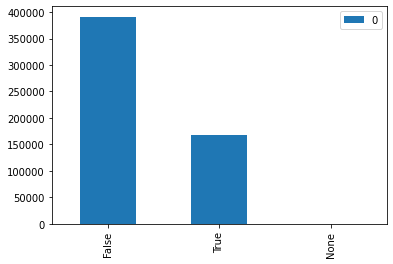

In [129]:
pd.DataFrame.from_dict(Counter(classes),orient='index').plot.bar()

## Build function 
## freq_atribclss_prod(attribute,df_column)
which takes name of attribite and dataframe column as parameter
and returns dataframe containing classes with their frequency


In [24]:
def freq_attribclss_prod(attribute,df_column):
        attrib = attribute
        classes = []
        cnt =0
        for string in df_column:
            for dct in json.loads(string):
                for k,v in dct.items():
                    #print(k)
                    # check if attribute matches key
                    # and if value is string then just append it to classes

                    if k==attrib:
                        if isinstance(v,str):
                            classes.append(v)

                    try:
                        for k1,v1 in v.items():
                            total_counter+=1
                            if k1==attrib:
                                classes.append(v1)
                            #print(k1,v1)

                    except Exception as e:
                        if k1==attrib:
                                classes.append(v1)
                        pass
            # print how many products are processed so far
            if cnt%100 == 0:
                print('product: ',str(cnt),'processed')
            cnt+=1
        # now return frequecny table
        return pd.DataFrame.from_dict(Counter(classes),orient='index')

In [118]:
freq_attribclss_prod('Closure',products.products)

product:  0 processed
product:  100 processed
product:  200 processed
product:  300 processed
product:  400 processed
product:  500 processed
product:  600 processed
product:  700 processed
product:  800 processed


""


## Raw practice


### process single row of proucts column
and get frequency distribution of primary keys and secondary keys

In [30]:
'''
This code block work on single row of product.products
It is for testing and general unserstanding of structure of data
'''

# so we have one row of products column as string

string = products.products[0]
# initiate counters to track number of exceptions accuring etc
str_counter=0
total_counter=0

# pass attributes varible for which classes freuency has to measuered
attrib = 'ebay'
# we need list variable to append each class for given attribute
# we will loop through data string and will append each class entry in classes list

classes = []
# main loop to iterate over elements inside main list string returned by json.loads() method
for dct in json.loads(string):
    # now process nested dictioneries
    # zero level dictioneries
    for k,v in dct.items():
        # check if attribute matches key
        # and if value is string then just append it to classes
        # if dict's contains key value pair as string, please append
        if k==attrib:
            # if value is nested it means we have simple dictionery instead of nested dictionary
            if isinstance(v,str):
                classes.append(v)        
        try:
            for k1,v1 in v.items():
                total_counter+=1
                if k1==attrib:
                    classes.append(v1)
                #print(k1,v1)
                
        except Exception as e:
            total_counter+=1
            if k1==attrib:
                    classes.append(v1)
            str_counter+=1
            pass
Counter(classes)

Counter()

In [32]:
'''
here we modify above code to 
get process each row insdie proucts.products column
'''

str_counter=0
total_counter=0
attrib = 'ebay'
classes = []
cnt =0
for string in products.products:
    for dct in json.loads(string):
        for k,v in dct.items():
            #print(k)
            # check if attribute matches key
            # and if value is string then just append it to classes

            if k==attrib:
                if isinstance(v,str):
                    classes.append(v)

            try:
                for k1,v1 in v.items():
                    total_counter+=1
                    if k1==attrib:
                        classes.append(v1)
                    #print(k1,v1)

            except Exception as e:
                total_counter+=1
                if k1==attrib:
                        classes.append(v1)
                str_counter+=1
                pass
    if cnt%100 == 0:
        print('product: ',str(cnt),'processed')
    cnt+=1

Counter(classes)

product:  0 processed
product:  100 processed
product:  200 processed
product:  300 processed
product:  400 processed
product:  500 processed
product:  600 processed
product:  700 processed
product:  800 processed


Counter()